# 07. FASTopic Modeling

This notebook implements a modern topic modeling pipeline using FASTopic.
It leverages precomputed multilingual embeddings from Phase 1, conducts a robust grid search
for hyperparameters, and trains a final model on the full dataset while ensuring memory efficiency
and exact reproducibility.

In [1]:
import os
import gc
import json
import torch
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import importlib.util
import subprocess
import sys

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def check_and_install(package_name, pip_name=None):
    if pip_name is None:
        pip_name = package_name
    if importlib.util.find_spec(package_name) is None:
        if IN_COLAB:
            print(f"Installing {pip_name} in Colab...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
        else:
            print(f"Warning: '{package_name}' is missing. Make sure to install '{pip_name}' in your local .venv")

check_and_install("fastopic")
check_and_install("topmost")

# FASTopic & dependencies
from fastopic import FASTopic
import topmost
from topmost.eva import topic_diversity, topic_coherence

if IN_COLAB:
    drive.mount('/content/drive')
    BASE_PATH = Path("/content/drive/Shareddrives/Minería/proyecto_horus/")
    # BASE_PATH = Path("/content/drive/MyDrive/proyecto_horus/")
else:
    BASE_PATH = Path("../")

# Configurations
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

PROCESSED_DATA_PATH = BASE_PATH / "data/processed/products_modeling.parquet"
EMBEDDINGS_PATH = BASE_PATH / "data/processed/final_embeddings_matrix.npy"

CHECKPOINT_PATH = BASE_PATH / "outputs/07_fastopic_gridsearch_checkpoint.json"
THETA_OUTPUT_PATH = BASE_PATH / "outputs/07_fastopic_theta.parquet"
METRICS_OUTPUT_PATH = BASE_PATH / "outputs/07_fastopic_metrics.csv"
TUNING_SPLIT_PATH = BASE_PATH / "data/processed/tuning_split_indices.json"

USE_FULL_CORPUS = False
SAMPLE_FRACTION = 0.40

Installing fastopic in Colab...
Mounted at /content/drive


## 1. Load Data & Embeddings

In [2]:
print("Loading parquet dataset...")
df = pd.read_parquet(PROCESSED_DATA_PATH)
print(f"Dataset shape: {df.shape}")

print("Loading precomputed embeddings matrix...")
embeddings_matrix = np.load(EMBEDDINGS_PATH).astype(np.float32)
print(f"Embeddings shape: {embeddings_matrix.shape}")

# Validate shapes match
assert len(df) == embeddings_matrix.shape[0], "Mismatch between dataframe and embeddings!"

# Retrieve full docs
docs = df['embeddings_text'].tolist()

Loading parquet dataset...
Dataset shape: (99064, 16)
Loading precomputed embeddings matrix...
Embeddings shape: (99064, 1024)


## 2. Embedder Integration
We define `PrecomputedJinaEmbedder` which maps the `docs` list back to the static `final_embeddings_matrix.npy`
efficiently using a fast `Dict[str, int]` mapping.

In [3]:
class PrecomputedJinaEmbedder:
    def __init__(self, original_docs: list, embeddings: np.ndarray):
        """
        Maps text to its exact row index in the precomputed embeddings matrix.
        We use a strict mapping from the text to the original index.
        """
        self.embeddings = embeddings

        # Build Dict[str, int] for O(1) lookup and extreme memory efficiency
        self.mapping = {}
        for idx, doc in enumerate(original_docs):
            # If there are duplicates, we keep the first occurrence index.
            # In our dataset context, documents are mostly unique or deduplicated.
            if doc not in self.mapping:
                self.mapping[doc] = idx

        self.last_queried_indices = []

    def reset_tracker(self):
        """Cleans the state before starting a new modeling cycle."""
        self.last_queried_indices = []

    def encode(self, query_docs: list, **kwargs) -> np.ndarray:
        """
        Returns the embeddings for the requested docs by slicing the static matrix via fancy indexing.
        (Accepts **kwargs to gracefully ignore arguments like 'show_progress_bar' or 'normalize_embeddings' passed by FASTopic)
        """
        batch_indices = []
        for doc in query_docs:
            if doc in self.mapping:
                batch_indices.append(self.mapping[doc])
            else:
                raise ValueError(f"Document not found in precomputed embeddings mapping!")

        # Accumulate the indices globally for the final alignment
        self.last_queried_indices.extend(batch_indices)

        # Fancy indexing directly on the static matrix
        return self.embeddings[batch_indices]

embedder = PrecomputedJinaEmbedder(original_docs=docs, embeddings=embeddings_matrix)
print("Embedder initialized.")

Embedder initialized.


## 3. Sampling & Preprocessing

In [4]:
if USE_FULL_CORPUS:
    print("Using 100% of the corpus for tuning.")
    tuning_indices = np.arange(len(df)).tolist()
else:
    print(f"Using {SAMPLE_FRACTION*100}% random sample for tuning.")
    if TUNING_SPLIT_PATH.exists():
        print(f"Loading existing split from {TUNING_SPLIT_PATH}")
        with open(TUNING_SPLIT_PATH, 'r') as f:
            tuning_indices = json.load(f)
    else:
        tuning_indices = np.random.choice(len(df), size=int(len(df) * SAMPLE_FRACTION), replace=False).tolist()
        with open(TUNING_SPLIT_PATH, 'w') as f:
            json.dump(tuning_indices, f)
        print(f"Created and saved new tuning split of size {len(tuning_indices)}")

tuning_docs = [docs[i] for i in tuning_indices]

# FASTopic relies on topmost for creating the Bag of Words (BoW)
preprocess = topmost.preprocess.Preprocess(vocab_size=15000)

Using 40.0% random sample for tuning.
Loading existing split from /content/drive/Shareddrives/Minería/proyecto_horus/data/processed/tuning_split_indices.json


## 4. Robust Grid Search
We search over K values and DT_alpha, saving progress to intercept OOM or timeout issues.

In [5]:
# Grid Search Space
K_VALUES = [28, 100, 200, 310]
ALPHA_VALUES = [5.0, 10.0, 15.0]

# Load checkpoint if exists
if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH, 'r') as f:
        results = json.load(f)
    print(f"Loaded checkpoint with {len(results)} completed runs.")
else:
    results = []

def get_run_id(k, alpha):
    return f"K_{k}_alpha_{alpha}"

completed_runs = {res['run_id'] for res in results}

print("Preparing dataset for topmost metrics...")
# This call tokenizes and extracts the vocab needed for evaluation
dataset_dict = preprocess.preprocess(tuning_docs)
vocab = dataset_dict['vocab']
parsed_texts = dataset_dict['train_texts']

for k in K_VALUES:
    for alpha in ALPHA_VALUES:
        run_id = get_run_id(k, alpha)

        if run_id in completed_runs:
            print(f"Skipping {run_id}, already computed.")
            continue

        print(f"\n--- Running Config: {run_id} ---")

        try:
            # Reset the tracker before iterating over the batches for this configuration
            embedder.reset_tracker()

            # Initialize Model
            model = FASTopic(
                num_topics=k,
                preprocess=preprocess,
                doc_embed_model=embedder,
                DT_alpha=alpha,
                low_memory=True,
                low_memory_batch_size=5000
            )

            # Pass the raw list so the embedder receives the exact keys
            # FASTopic will handle passing it to topmost internally
            top_words, train_theta = model.fit_transform(tuning_docs)

            # Compute Metrics
            # Topic Diversity (PUV)
            # In topmost>=1.0, we use the `_diversity` function and manually slice for topk=10
            top_words_10 = [" ".join(words.split()[:10]) for words in top_words]
            puv = topic_diversity._diversity(top_words_10)

            # Topic Coherence (NPMI)
            npmi = topic_coherence._coherence(
                reference_corpus=parsed_texts,
                vocab=vocab,
                top_words=top_words,
                coherence_type='c_npmi',
                topn=10
            )

            print(f"Result - PUV: {puv:.4f}, NPMI: {npmi:.4f}")

            # Save progress
            results.append({
                'run_id': run_id,
                'K': k,
                'alpha': alpha,
                'PUV': float(puv),
                'NPMI': float(npmi)
            })

            with open(CHECKPOINT_PATH, 'w') as f:
                json.dump(results, f, indent=4)

        except Exception as e:
            print(f"Error encountered during {run_id}: {e}")
            raise e

        finally:
            # AGGRESSIVE MEMORY CLEANUP
            if 'model' in locals():
                del model
            gc.collect()
            torch.cuda.empty_cache()

Loaded checkpoint with 9 completed runs.
Preparing dataset for topmost metrics...


parsing texts: 100%|██████████| 39625/39625 [00:05<00:00, 7331.51it/s]
2026-06-01 19:25:31,632 - TopMost - Real vocab size: 15000
2026-06-01 19:25:31,640 - TopMost - Real training size: 39625 	 avg length: 72.952


Skipping K_28_alpha_5.0, already computed.
Skipping K_28_alpha_10.0, already computed.
Skipping K_28_alpha_15.0, already computed.
Skipping K_100_alpha_5.0, already computed.
Skipping K_100_alpha_10.0, already computed.
Skipping K_100_alpha_15.0, already computed.
Skipping K_200_alpha_5.0, already computed.
Skipping K_200_alpha_10.0, already computed.
Skipping K_200_alpha_15.0, already computed.

--- Running Config: K_310_alpha_5.0 ---


parsing texts: 100%|██████████| 39625/39625 [00:07<00:00, 5446.15it/s]
2026-06-01 19:25:53,180 - TopMost - Real vocab size: 15000
2026-06-01 19:25:53,185 - TopMost - Real training size: 39625 	 avg length: 72.952
Training FASTopic: 100%|██████████| 200/200 [21:19<00:00,  6.40s/it]


Result - PUV: 0.6365, NPMI: -0.2188

--- Running Config: K_310_alpha_10.0 ---


parsing texts: 100%|██████████| 39625/39625 [00:06<00:00, 6003.20it/s]
2026-06-01 19:48:30,960 - TopMost - Real vocab size: 15000
2026-06-01 19:48:30,966 - TopMost - Real training size: 39625 	 avg length: 72.952
Training FASTopic: 100%|██████████| 200/200 [19:16<00:00,  5.78s/it]


Result - PUV: 0.5329, NPMI: -0.1390

--- Running Config: K_310_alpha_15.0 ---


parsing texts: 100%|██████████| 39625/39625 [00:07<00:00, 5319.96it/s]
2026-06-01 20:09:04,450 - TopMost - Real vocab size: 15000
2026-06-01 20:09:04,456 - TopMost - Real training size: 39625 	 avg length: 72.952
Training FASTopic: 100%|██████████| 200/200 [19:25<00:00,  5.83s/it]


Result - PUV: 0.4935, NPMI: -0.1204


## 5. Pareto Frontier Visualization

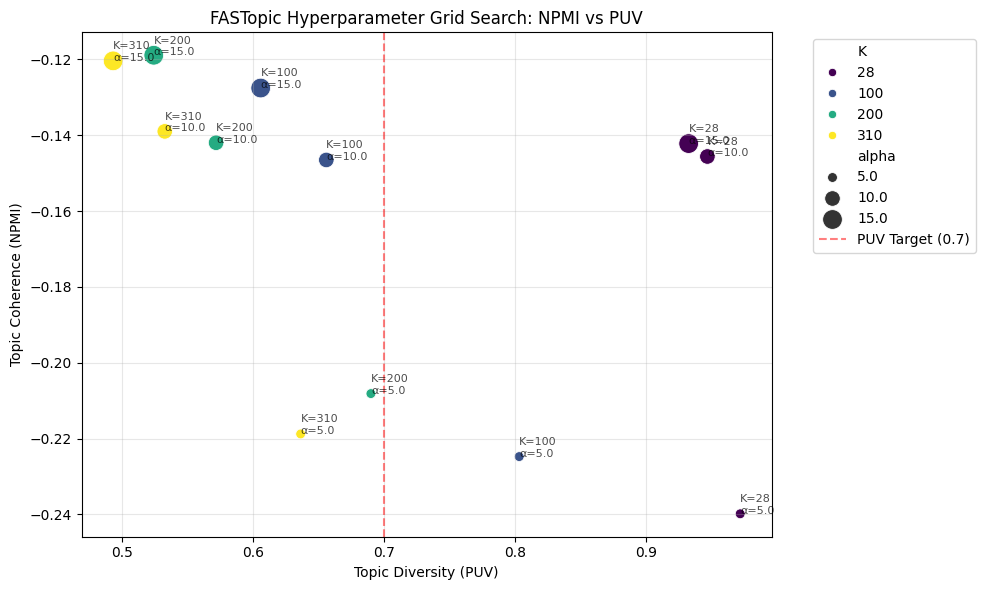

In [6]:
results_df = pd.DataFrame(results)

if not results_df.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=results_df,
        x='PUV',
        y='NPMI',
        hue='K',
        size='alpha',
        sizes=(50, 200),
        palette='viridis'
    )

    # Highlight valid region (PUV >= 0.7)
    plt.axvline(x=0.7, color='r', linestyle='--', alpha=0.5, label='PUV Target (0.7)')

    for i in range(len(results_df)):
        plt.text(
            results_df['PUV'].iloc[i],
            results_df['NPMI'].iloc[i],
            f"K={results_df['K'].iloc[i]}\nα={results_df['alpha'].iloc[i]}",
            fontsize=8, alpha=0.7
        )

    plt.title('FASTopic Hyperparameter Grid Search: NPMI vs PUV')
    plt.xlabel('Topic Diversity (PUV)')
    plt.ylabel('Topic Coherence (NPMI)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No results available to plot.")

## 6. Full Scale Retraining
We select the best hyperparameters (maximizing NPMI while maintaining PUV >= 0.70) and retrain on the 100% corpus.

In [7]:
if not results_df.empty:
    # Find best config
    valid_configs = results_df[results_df['PUV'] >= 0.70]

    if not valid_configs.empty:
        best_config = valid_configs.loc[valid_configs['NPMI'].idxmax()]
    else:
        print("Warning: No config reached PUV >= 0.70. Defaulting to absolute max NPMI.")
        best_config = results_df.loc[results_df['NPMI'].idxmax()]

    best_k = int(best_config['K'])
    best_alpha = float(best_config['alpha'])

    print(f"Selected Best Hyperparameters -> K: {best_k}, alpha: {best_alpha}")

    print("\n--- Retraining on Full 100% Corpus ---")
    full_preprocess = topmost.preprocess.Preprocess(vocab_size=15000)

    # The FASTopic model requires raw texts to maintain exact string matching
    # against the embedder's pre-computed keys. Topmost will do the BoW transformation internally.

    try:
        # Reset tracker before final training
        embedder.reset_tracker()

        final_model = FASTopic(
            num_topics=best_k,
            preprocess=full_preprocess,
            doc_embed_model=embedder,
            DT_alpha=best_alpha,
            low_memory=True,
            low_memory_batch_size=5000
        )

        # Pass the original raw list
        final_top_words, final_train_theta = final_model.fit_transform(docs)

        # Save the distribution to Parquet
        print("Saving Theta distributions...")
        theta_df = pd.DataFrame(final_train_theta)

        # Ensure the exact mathematical alignment with the filtered documents
        theta_df.index = df.index[embedder.last_queried_indices]
        theta_df.to_parquet(THETA_OUTPUT_PATH)
        print(f"Theta distributions saved to {THETA_OUTPUT_PATH}")

        # Save metrics
        metrics_df = best_config.to_frame().T
        metrics_df.to_csv(METRICS_OUTPUT_PATH, index=False)
        print(f"Metrics saved to {METRICS_OUTPUT_PATH}")
        print("Full retraining complete and artifacts saved.")

    finally:
        if 'final_model' in locals():
            del final_model
        gc.collect()
        torch.cuda.empty_cache()
else:
    print("Skipping full retraining: Grid search results are empty.")

Selected Best Hyperparameters -> K: 28, alpha: 15.0

--- Retraining on Full 100% Corpus ---


parsing texts: 100%|██████████| 99064/99064 [00:15<00:00, 6392.46it/s]
2026-06-01 20:30:13,562 - TopMost - Real vocab size: 15000
2026-06-01 20:30:13,575 - TopMost - Real training size: 99064 	 avg length: 72.967
Training FASTopic: 100%|██████████| 200/200 [40:28<00:00, 12.14s/it]


Saving Theta distributions...
Theta distributions saved to /content/drive/Shareddrives/Minería/proyecto_horus/outputs/07_fastopic_theta.parquet
Metrics saved to /content/drive/Shareddrives/Minería/proyecto_horus/outputs/07_fastopic_metrics.csv
Full retraining complete and artifacts saved.


# 7. References / Bibliography

* **FASTopic: Pretrained Transformer is a Fast, Adaptive, Stable, and Transferable Topic Model**
  * Paper: [arXiv:2405.17978](https://arxiv.org/abs/2405.17978)
  * GitHub: [bobxwu/FASTopic](https://github.com/bobxwu/FASTopic)
  * BibTeX:
    ```bibtex
    @inproceedings{wu2024fastopic,
        title={FASTopic: Pretrained Transformer is a Fast, Adaptive, Stable, and Transferable Topic Model},
        author={Wu, Xiaobao and Nguyen, Thong Thanh and Zhang, Delvin Ce and Wang, William Yang and Luu, Anh Tuan},
        booktitle={The Thirty-eighth Annual Conference on Neural Information Processing Systems},
        year={2024}
    }
    ```